# Exercise 11: The beauty of kNN

In this exercise, you'll gain practice working with kNN. We'll use the [diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) dataset, which comes as part of `ggplot2`. This dataset provides information on the quality and price of 50,000 diamonds.


-----
## 1. Data, Plotting, and Train/Test Sets (2 points)
* Load the the `class` and `tidyverse` packages.
* Assign the `diamonds` data set to a simpler name. Then, create a new variable `price_bin` that splits the `price` variable into a binary variable, where 1 indicates that the diamond costs greater than the mean price, and 0 indicates that the diamond costs less than the mean price. Set `price_bin` to be a factor. (*Hint: use the if_else() function*)
* Select just the `carat`, `depth`, `table`, `x`, `y`, and your new `price_bin` variables
* Print the first few lines of the data set
* Print the dimensions of the data set


In [3]:
library(class)
library(tidyverse)

df <- diamonds %>%
mutate(price_bin = case_when(price > mean(price, na.rm = T) ~ 1,
                             price < mean(price, na.rm = T) ~ 0)) %>%
select(c(carat, depth, table, x, y, price_bin)) %>%
mutate(price_bin = as.factor(price_bin))

head(df)
str(df)

carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0.23,61.5,55,3.95,3.98,0
0.21,59.8,61,3.89,3.84,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0


tibble [53,940 × 6] (S3: tbl_df/tbl/data.frame)
 $ carat    : num [1:53940] 0.23 0.21 0.23 0.29 0.31 0.24 0.24 0.26 0.22 0.23 ...
 $ depth    : num [1:53940] 61.5 59.8 56.9 62.4 63.3 62.8 62.3 61.9 65.1 59.4 ...
 $ table    : num [1:53940] 55 61 65 58 58 57 57 55 61 61 ...
 $ x        : num [1:53940] 3.95 3.89 4.05 4.2 4.34 3.94 3.95 4.07 3.87 4 ...
 $ y        : num [1:53940] 3.98 3.84 4.07 4.23 4.35 3.96 3.98 4.11 3.78 4.05 ...
 $ price_bin: Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 1 1 ...


### Plot
Create a scatterplot of the link between `carat` and `depth`, and use the `color` aesthetics mapping to differentiate between diamonds that cost above versus below the mean price.

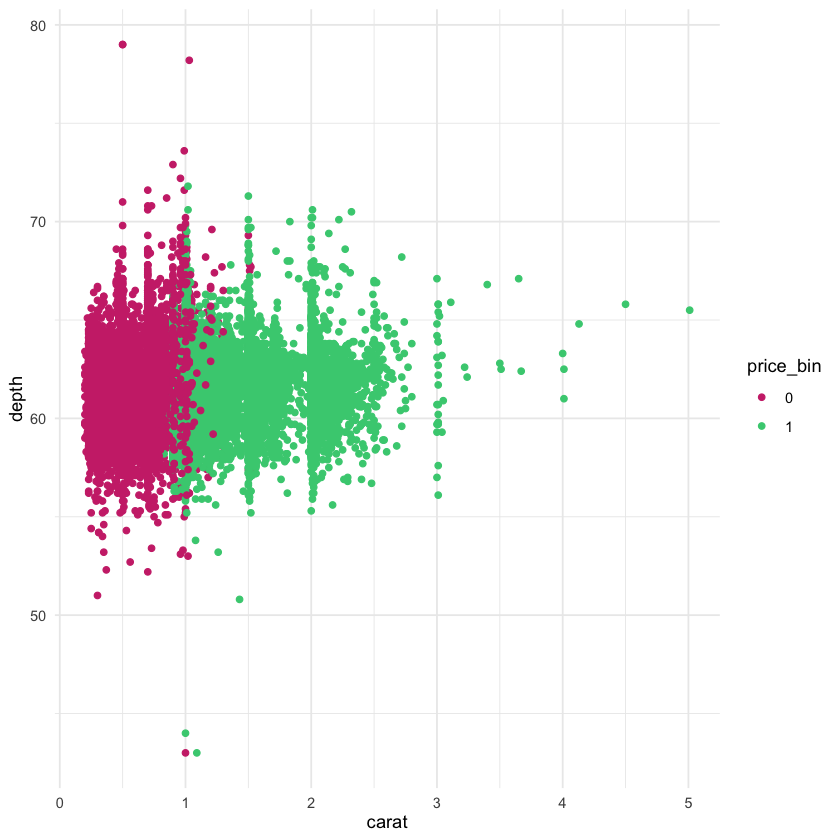

In [11]:
ggplot(df, aes(x = carat, y = depth, color = price_bin)) +
geom_point() + 
scale_color_manual(values = c("0" = "violet red 3", "1" = "seagreen3")) + 
theme_minimal()

Based on the above scatterplot, how do you think kNN will perform using only these two variables to predict diabetes diagnosis? Which variable, carat or depth, gives us the most information about which price class the diamond will belong to?
> Carat. kNN should be able to predict the price bin of the diamond based on carat, rather than depth. The data are clustered clearly according to the carat, whereas both price bins cluster around similar depth ranges. 

### Test vs Train

Before we run KNN on these data, we need to set aside a portion of the observations as our test set. Below, randomly divide the data such that 30% are allotted to the `test` set and the rest are allotted to the `train` set. Print the first few lines of each set, and print the dimensions of each set to double check your division of the data.

In [36]:
set.seed(2023)
test_set <- 0.3 * nrow(df)

rand_idx <- sample(1:nrow(df), test_set)

df_test <- df %>% slice(rand_idx) %>% select(c(carat, depth)) # select specified rows
df_train <- df %>% slice(-rand_idx) %>% select(c(carat, depth)) # select remaining rows
train_spec <- df %>% slice(-rand_idx) %>% select(price_bin)

head(df_test)
str(df_test) 

head(df_train)
str(df_train)

carat,depth
<dbl>,<dbl>
1.22,62.3
1.57,62.3
1.11,62.4
0.42,60.6
0.32,62.6
0.90,62.7


tibble [16,182 × 2] (S3: tbl_df/tbl/data.frame)
 $ carat: num [1:16182] 1.22 1.57 1.11 0.42 0.32 0.9 1.09 0.53 0.23 0.55 ...
 $ depth: num [1:16182] 62.3 62.3 62.4 60.6 62.6 62.7 62.5 62.2 60.4 61.3 ...


carat,depth
<dbl>,<dbl>
0.23,61.5
0.23,56.9
0.29,62.4
0.31,63.3
0.24,62.8
0.24,62.3


tibble [37,758 × 2] (S3: tbl_df/tbl/data.frame)
 $ carat: num [1:37758] 0.23 0.23 0.29 0.31 0.24 0.24 0.26 0.22 0.23 0.23 ...
 $ depth: num [1:37758] 61.5 56.9 62.4 63.3 62.8 62.3 61.9 65.1 59.4 62.8 ...


-----
## 2. KNN (3 points)
Now, use the `knn()` function from the `class` library to predict `price_bin` from the `carat` and `depth`. Set `k = 3`.

*Hint: Review the format required for the arguments of knn()*

In [37]:
set.seed(2023)
knn_model <- knn(df_train, df_test, train_spec$price_bin, k = 3)

Now, output a confusion matrix and calculate the test error to evaluate model performance.

In [38]:
cf_matrix <- function(model, actual){
    cf_df <- data.frame(predicted = model, actual = actual)
    print(table(cf_df))
    x <- mean(cf_df$predicted == cf_df$actual)
    return(x)
}

cf_matrix(knn_model, df$price_bin[rand_idx])

         actual
predicted    0    1
        0 9707  316
        1  539 5620


[1] 0.9471635

How did your model perform?
> It appears to have performed really well. 


Let's try to improve our model by adding all of the other variables in our data set as predictors. Rerun your `knn()` below, keeping `k = 3`. Again, output a confusion matrix and error rate for your updated model fit.

In [39]:
set.seed(2023)

df_test_2 <- df %>% slice(rand_idx)
df_train_2 <- df %>% slice(-rand_idx)
train_spec <- df %>% slice(-rand_idx) %>% select(price_bin)

knn_model_2 <- knn(df_train_2, df_test_2, train_spec$price_bin, k = 3)
cf_matrix(knn_model_2, df$price_bin[rand_idx])

         actual
predicted     0     1
        0 10237    10
        1     9  5926


[1] 0.9988259

Did your model predictions improve?
> Yes, but only slightly because the model was already performing close to ceiling.

-----
## 3. For loop (3 points)

So adding additional predictors didn't shift our error much. Let's see if adjusting `k` has a larger impact on model accuracy.

Using your initial model above with just `carat` and `depth`, run a `for loop` that runs the same model 30 times, for `k = 1:30`.

Output a data frame that has `k` and the overall `error` as columns.

The structure of the output data frame and `for loop` are provided for you below. Note that your loop will take a minute or two to run because there are so many observations in the dataset. It may be helpful while you are writing and testing your loop to run it on a subset of the data with only a handful of rows.

In [40]:
output  <- data.frame(k = seq(1:30),
                     error = rep(NA, 30))
head(output)

set.seed(2023)
output_temp <- data.frame(k = seq(1:30),
                          error = rep(NA, 30))

output_temp <- output_temp %>%
mutate(error = unlist(lapply(k, function(i){
        knn_model <- knn(df_train, df_test, train_spec$price_bin, k = i)
        cf_df <- data.frame(predicted = knn_model, actual = df$price_bin[rand_idx])
        table(cf_df)
        x <- mean(cf_df$predicted == cf_df$actual)
        return(x)
        })))

head(output_temp)
str(output_temp)

,k,error
,<int>,<lgl>
1,1,NA
2,2,NA
3,3,NA
4,4,NA
5,5,NA
6,6,NA


,k,error
,<int>,<dbl>
1,1,0.9463602
2,2,0.9466691
3,3,0.9458658
4,4,0.9467309
5,5,0.9474107
6,6,0.9473489


'data.frame':	30 obs. of  2 variables:
 $ k    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ error: num  0.946 0.947 0.946 0.947 0.947 ...


In [41]:
for (k in seq(1:30)) {
    knn_fits  <- knn(df_train, df_test, train_spec$price_bin, k = k)

    #overall error
    conf_df  <- data.frame(predicted = knn_model, actual = df$price_bin[rand_idx])
    output$error[k]  <- mean(conf_df$predicted == conf_df$actual) 
}
head(output)

,k,error
,<int>,<dbl>
1,1,0.9471635
2,2,0.9471635
3,3,0.9471635
4,4,0.9471635
5,5,0.9471635
6,6,0.9471635


Create a line plot of your `output` object using `ggplot`. Add a (non-linear) `geom_smooth` layer.

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


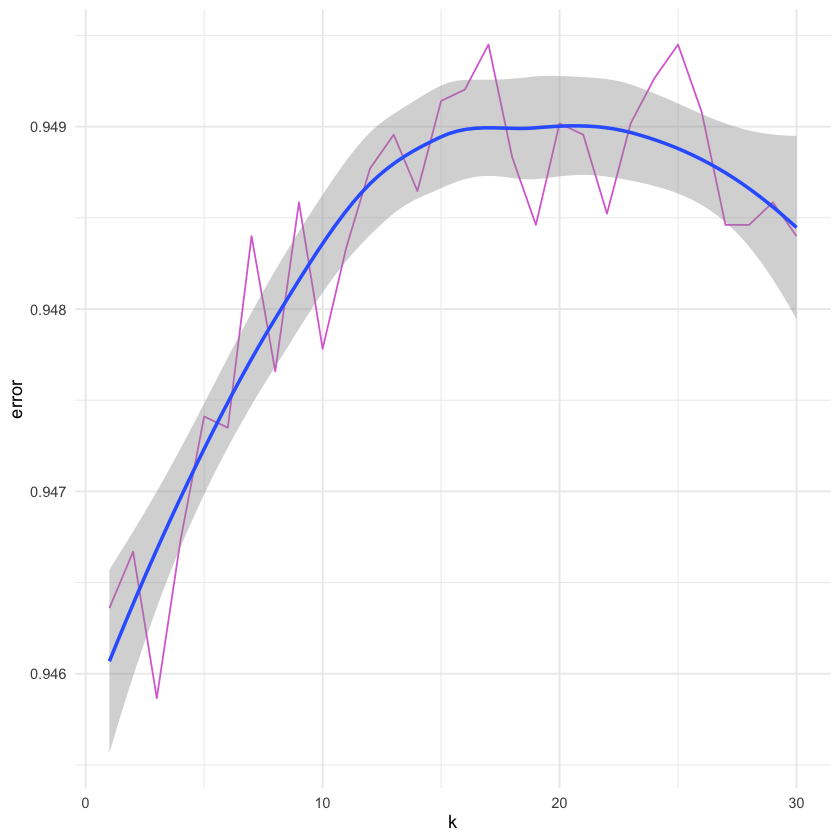

In [42]:
library(ggplot2)

ggplot(data = output_temp, aes(x = k, y = error)) +
    geom_line(col = 'orchid') +
    geom_smooth() +
    theme_minimal()

Interpret your plot. What would you select as the best value of `k`? How much does this improve your test error?
> The accuracy of the model increases linearly with the number of folds. However, this plateaus from k = 15, and dips slightly at k = 25. Since the improvement in the model peaks at k = 15, I would select k = 15 as the best value, since it improves the model from 0.946 to 0.949. 

-----
## 4. Standardizing predictors (2 points)

Because knn is based on distances between points, it is very sensitive to the scale of your variables. Looking at our predictor variables, we can see that `carat` and `depth` are orders of magnitude different in terms of scales. Maybe we can improve our fit even more by addressing this!

Below, use the `scale()` function to standardize your predictors. (Note that you don't need to standardize `price_bin`.)

Then, run your model a final time with your standardized predictors (just `carat` and `depth` still). Set `k` to the optimal value you determined in your plot above. Output the confusion matrix and error rate again.

In [43]:
set.seed(2023)

df_test_scale <- df %>% slice(rand_idx)%>%select(c(carat, depth))%>%mutate(across(everything(),scale))   
df_train_scale <- df %>% slice(-rand_idx)%>%select(c(carat, depth))%>%mutate(across(everything(),scale))   
train_spec <- df %>% slice(-rand_idx)%>%select(price_bin)

# INSERT CODE HERE
knn_model_3 <- knn(df_train_scale, df_test_scale, train_spec$price_bin, k = 3)
cf_matrix(knn_model_3, df$price_bin[rand_idx])

         actual
predicted    0    1
        0 9721  314
        1  525 5622


[1] 0.9481523

What impact did rescaling the data have on your error rate?
> It increased the prediction accuracy of the model, from 0.947 to 0.948.


**DUE:** 11:59pm March 17, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> I did not collaborate with any of my classmates on this assignment.  


**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.
> I did not utilize any generative AI tools on this assignment. 